# Проект: семантический поиск товаров по текстовому запросу

**Ваша роль.** Вы специалист по Data Science. Компания развивает онлайн-каталог товаров, и сейчас руководству кажется, что классический поиск по ключевым словам плохо справляется с реальными запросами. Пользователи пишут названия с ошибками, кириллицей, используют просторечные слова, ищут товары по назначению, а не по функциональности («удобные кроссовки для бега» вместо «мужские спортивные кроссовки с амортизацией»). Команда хочет проверить, поможет ли векторный поиск улучшить качество поисковой системы.

**Задача.** Вам нужно построить MVP системы семантического поиска, сравнить его с лексической baseline-моделью на подготовленной разметке и дать бизнесу обоснованную рекомендацию о том, где новое решение помогает, где ошибается и стоит ли его вообще внедрять.

## Данные

| Файл | Что это | Когда нужен |
|---|---|---|
| wb_products_raw_sample.parquet | Исходный каталог, ~200 тысяч строк, все категории. <br> Вам нужно самостоятельно отобрать рабочее подмножество этих данных | Недели 1–2 |
| wb_products_dedup.parquet | Пул асессоров: множество товаров, по которому делалась разметка | Неделя 2, раздел 4 |
| queries_synthetic_train.parquet | Разметка релевантности, train | Недели 2–3 |
| queries_synthetic_test.parquet | Разметка релевантности, test | **один прогон** в конце недели 3 |

Файлы с разметкой содержат четыре столбца: `query_id`, `query_text`, `item_id`, `relevance`. Шкала в `relevance` от `0` до `3`, где `0` — товар нерелевантен, а `3` — максимально релевантен. Связь с каталогом: `item_id` ↔ `imt_id`.

In [1]:
# Устанавливаем зафиксированные версии в окружение текущего ядра.
from pathlib import Path

requirements_path = Path("requirements.txt")
if not requirements_path.exists():
    requirements_path = Path("ProjectMonth") / "requirements.txt"

%pip install -r {requirements_path}


Looking in indexes: https://pypi.org/simple, https://download.pytorch.org/whl/cu132
Note: you may need to restart the kernel to use updated packages.


Установка использует зафиксированные версии из `requirements.txt`. Если библиотеки установлены или изменены впервые, перезапустите ядро перед последовательным запуском тетради. При сдаче сохраняется результат запуска в уже подготовленном окружении; `requirements.txt` во время выполнения не перезаписывается.


In [2]:
# Импорты для загрузки данных, анализа, поиска и сохранения экспериментов.
import html
import os
import random
import re
from pathlib import Path
from time import perf_counter

import boto3
import matplotlib.pyplot as plt
import seaborn as sns
import mlflow
import numpy as np
import pandas as pd
import torch
from dotenv import load_dotenv
from IPython.display import display
from sentence_transformers import SentenceTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split


/home/danat/personal_projects/final_project_dse/venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# Показывать числа с 2 знаками после запятой в датафреймах pandas
pd.set_option('display.float_format', '{:.3f}'.format)

# Показывать все колонки (не скрывать их троеточием)
pd.set_option('display.max_columns', None)

# показывать все строки (не скрывать их троеточием)
pd.set_option('display.max_rows', None)

# не обрезать длинные строки, а показывать полностью
pd.set_option('display.max_colwidth', None)

# Устанавливает тему
sns.set_theme(style='whitegrid', palette='muted')


**Настройки воспроизводимости.** Во всех случайных операциях используется `SEED = 42`. Само число условно: оно фиксирует разбиение и выбор карточек для просмотра, а не улучшает метрики. Для графиков выбран seaborn с общей темой, чтобы таблицы и распределения было удобно сопоставлять. Эти параметры оформления на результаты поиска не влияют.


In [4]:
# Один seed для всех случайных операций.
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)


In [5]:
                                                                                                                                                                                                                                # Пути к данным и результатам.
PROJECT_DIR = Path.cwd()
if (PROJECT_DIR / "ProjectMonth").is_dir():
    PROJECT_DIR = PROJECT_DIR / "ProjectMonth"
FILES_DIR = PROJECT_DIR / "files"
ARTIFACTS_DIR = PROJECT_DIR / "artifacts"
FILES_DIR.mkdir(exist_ok=True)
ARTIFACTS_DIR.mkdir(exist_ok=True)
load_dotenv(PROJECT_DIR / ".env")


True

In [6]:
RAW_PRODUCTS_PATH = FILES_DIR / "wb_products_raw_sample.parquet"
ASSESSED_POOL_PATH = FILES_DIR / "wb_products_dedup.parquet"
TRAIN_QUERIES_PATH = FILES_DIR / "queries_synthetic_train.parquet"
TEST_QUERIES_PATH = FILES_DIR / "queries_synthetic_test.parquet"


In [7]:
# Подключение к S3. Ключи хранятся в .env.
s3 = boto3.client(
    "s3",
    endpoint_url=os.getenv("S3_ENDPOINT_URL", "https://storage.yandexcloud.net"),
    aws_access_key_id=os.getenv("AWS_ACCESS_KEY_ID"),
    aws_secret_access_key=os.getenv("AWS_SECRET_ACCESS_KEY"),
    region_name="ru-central1",
)


In [8]:
# Существующие файлы повторно не скачиваем.
for path in [RAW_PRODUCTS_PATH, ASSESSED_POOL_PATH, TRAIN_QUERIES_PATH, TEST_QUERIES_PATH]:
    if path.exists() and path.stat().st_size > 0: # проверка что файл существует и не пустой
        print("Уже скачан:", path.name)
    else:
        temporary_path = path.with_suffix(".parquet.part") # временный файл, чтобы не оставлять пустой файл при прерывании скачивания
        s3.download_file("s3-ds-source", path.name, str(temporary_path))
        temporary_path.replace(path)
        print("Скачан:", path.name)


Уже скачан: wb_products_raw_sample.parquet
Уже скачан: wb_products_dedup.parquet
Уже скачан: queries_synthetic_train.parquet
Уже скачан: queries_synthetic_test.parquet


---

## Неделя 1 — знакомство с данными и EDA

**Цель** — понять, с какими данными работаете, чтобы принять обоснованные решения:

- выбрать категории, с которыми будете работать;
- определить, как будете очищать описания от всего лишнего;
- решить, из каких полей собирать текст товара.

**Главный критерий успеха:** любое ваше решение по данным вы можете подкрепить ссылкой на конкретные результаты анализа.

### 1. Загрузка данных

Загрузите каталог и обе разметки. Изучите их структуру: проанализируйте колонки и типы данных в них, определите, что описывает одна строка.

**Подсказка.** `imt_id` — карточка товара, `nm_id` — конкретный артикул этого товара, то есть его разновидность, отличающаяся цветом, размером или чем-то ещё. Определите, что из этого должен возвращать поиск, — от этого зависит, на каком уровне вы будете строить индекс.

In [9]:
# Загрузка данных в датафреймы pandas
df_raw = pd.read_parquet(RAW_PRODUCTS_PATH)
queries_train = pd.read_parquet(TRAIN_QUERIES_PATH)
accessed_pool = pd.read_parquet(ASSESSED_POOL_PATH)

In [10]:
df_raw.info()


<class 'pandas.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 9 columns):
 #   Column           Non-Null Count   Dtype
---  ------           --------------   -----
 0   imt_id           200000 non-null  int64
 1   nm_id            200000 non-null  int64
 2   imt_name         200000 non-null  str  
 3   subj_name        200000 non-null  str  
 4   subj_root_name   200000 non-null  str  
 5   nm_colors_names  200000 non-null  str  
 6   vendor_code      200000 non-null  str  
 7   description      200000 non-null  str  
 8   brand_name       200000 non-null  str  
dtypes: int64(2), str(7)
memory usage: 169.5 MB


In [11]:
df_raw.head()


,imt_id,nm_id,imt_name,subj_name,subj_root_name,nm_colors_names,vendor_code,description,brand_name
0,100000,118982,Сумка,Сумки,Аксессуары,бежевый,82992/beige,,Pola
1,1000000,1206857,Шапка,Шапки,Головные уборы,белый,Лаки/белый,,Ваша Шляпка
2,1000000,1206860,Шапка,Шапки,Головные уборы,черный,Лаки/черный,,Ваша Шляпка
3,10000000,13349975,Очки TRUESPIN Fold,Солнцезащитные очки,Аксессуары,черный,20S.Y.T.35.00.564/Black/Black,,True Spin
4,10000001,13349981,Очки TRUESPIN Candor,Солнцезащитные очки,Аксессуары,черный,20S.Y.T.35.00.567/Black,,True Spin


In [12]:
queries_train.info()


<class 'pandas.DataFrame'>
RangeIndex: 11453 entries, 0 to 11452
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   query_id    11453 non-null  str  
 1   query_text  11453 non-null  str  
 2   item_id     11453 non-null  int64
 3   relevance   11453 non-null  int64
dtypes: int64(2), str(2)
memory usage: 854.8 KB


In [13]:
queries_train.head()


,query_id,query_text,item_id,relevance
0,SYN_000001,жилеты на пуговицах,100211,3
1,SYN_000001,жилеты на пуговицах,100433,1
2,SYN_000001,жилеты на пуговицах,1000988,1
3,SYN_000001,жилеты на пуговицах,1016032,1
4,SYN_000001,жилеты на пуговицах,10001023,1


In [14]:
accessed_pool.head()

,imt_id,nm_id,imt_name,subj_name,subj_root_name,nm_colors_names,vendor_code,description,brand_name
0,10060800,13433548,Платье женское миди с цветами,Платья,Одежда,"темно-синий, бордовый",19281VS/синий-цветы,"Платье женское шифоновое средней длины с расклешенной юбкой от линии талии. Втачной рукав с кружевыми вставками до локтя, боковая застежка на молнии. V - образный вырез с имитацией запаха зрительно вытягивает шею, делает грудь визуально пышнее. Цветочный принт на платье придаст вашему образу женственность и утонченность. Невесомая ткань платья и удобный фасон подарят вашим движениям комфорт и непревзойденную легкость. Важная информация! При заказе обращайте особое внимание на параметры изделия, указанные в таблице соответствия.",Velvet Season
1,10161088,13569174,"Футболка, Marvel Super Heroes, Марвел, белая футболка, футболка с принтом",Футболки,Одежда,белый,5557955579.60,"Заряжено мощью и суперспособностями, ведь на принте собрались вместе харизматичные и сверхсильные супергерои из вселенной Марвел. Сила духа, вера в победу и нотка авантюризма помогают решить самые фантастические задачи. Пусть все будет эпично! Белая, стильная футболка унисекс из хлопка. Гладкая и приятная на ощупь. Слегка приталенный крой добавит стильности в ваш образ. Чтобы принт долго вас радовал, рекомендуем стирку до 30 градусов, гладить в режиме для хлопка с изнаночной стороны.Мы рекомендуем стирать изделия с принтами при температуре не выше 30 С жидким моющим средством в деликатном или ручном режиме. Перед стиркой необходимо вывернуть вещь наизнанку. Максимально допустимая скорость отжима - 600 об/мин. Гладить можно с изнаночной стороны при температуре не выше 110 С. Отбеливание, барабанная сушка, химическая чистка могут испортить изделие. футболка / подарок / подарки на 23 февраля мужчинам / подарок февраля / Мстители",Marvel
2,10092680,13478275,Блузка / Топ / Футболка розовая,Блузки,Одежда,светло-розовый,МелиссаКалифрозовый,"Блузка из поливискозного трикотажного полотна. Прямая модель без вытачек с интеллигентным рукавом. Можно использовать в качестве топа под жакет. Модель свободного кроя, для более плотной посадки рекомендуем заказывать на размер меньше.",Марка Котовых
3,10118547,13513076,Женские джинсы прямые большие размеры / школьная,Джинсы,Одежда,синий,681SB/BLUE-2,"Стильные женские прямые джинсы больших размеров. Комфортный вариант для стильных и современных дам. Фасон выгодно подчеркивает достоинства фигуры и визуально удлинняет силуэт. Посадка высокая. Состоят на 98% из хлопка.Модель застегивается на пуговицу и молнию. Прямые джинсы от **TUUT VINTAGE DENIM STUDIO** станут идеальной базой в гардеробе любой девушки благодаря универсальности кроя. Благодаря своей универсальности могут быть составляющей любого образа. Комфортный вариант для повседневной носки. Незаменимый вариант для офиса. Стильный и модный вариант для праздника. TUUT VINTAGE DENIM STUDIO - знак качества, стиля и постоянства клиентов! Уважаемые покупатели, кликайте на название нашего бренда TUUT VINTAGE DENIM STUDIO и переходи в полный каталог. Там Вы найдёте изделия из денима: джинсы популярных моделей(клеш, палаццо , классические, прямые, бананы, бойфренды и т.д), джинсы больших размеров, джинсы с высокой и средней посадкой , куртки, шорты, капри, бриджи и многое другое.",TUUT VINTAGE DENIM STUDIO
4,10063800,13438109,Костюм зимний горнолыжный мембрана,Костюмы,Одежда,"фиолетовый, черный",КП-4002/фиолетовый,"Костюм зимний женский горнолыжный. Куртки с капюшоном и брюки на лямках бретелях которые можно регулировать по длине. Верхний слой мембранная водоотталкивающая ткань, которая сохраняет тепло, позволяет телу дышать и отводит лишнюю влагу, а внутри изделия имеется горнолыжная перелина для ветрозащиты. Рукава курточки снабжены манжетами, а брюки снизу защищены снегозащитным клапаном из непромокаемой ткани. Все это делает лыжный полукомбинезон идеальным вариантом не только для повседневных прогулок на природе, но и для занятий сноубордом, фитнесом, рыбалкой и даже катаний 

In [15]:
accessed_pool.info()

<class 'pandas.DataFrame'>
RangeIndex: 4256 entries, 0 to 4255
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   imt_id           4256 non-null   int64
 1   nm_id            4256 non-null   int64
 2   imt_name         4256 non-null   str  
 3   subj_name        4256 non-null   str  
 4   subj_root_name   4256 non-null   str  
 5   nm_colors_names  4256 non-null   str  
 6   vendor_code      4256 non-null   str  
 7   description      4256 non-null   str  
 8   brand_name       4256 non-null   str  
dtypes: int64(2), str(7)
memory usage: 3.1 MB


**Назначение данных.** Исходный каталог содержит 200 000 строк и девять полей; строка описывает вариант товара `nm_id`. В разметке train — 11 453 пары «запрос — карточка». Поиск возвращает карточку `imt_id`, которая соответствует `item_id` в разметке.

Файл `wb_products_dedup.parquet` содержит 4 256 карточек и используется далее только как список ID для каталога оценки. Просмотр его структуры не заменяет подготовку текстов из raw-каталога. Из финального test читаются только `query_id` и `query_text` для проверки пересечения с train. Оценки `relevance` не читаются и не используются при выборе модели.


**Проверьте связность данных:** все ли `item_id` из разметки есть в каталоге, нет ли пересечения `query_id` между `train` и `test`.

In [16]:
# Проверяем связь разметки с каталогом.
missing_items = queries_train.loc[~queries_train["item_id"].isin(df_raw["imt_id"])]
print("Товаров из разметки вне каталога:", missing_items["item_id"].nunique())
missing_items.head()


Товаров из разметки вне каталога: 0


,query_id,query_text,item_id,relevance


In [17]:
# Пропуски и повторные пары видны в таблице, а не скрыты в проверках.
display(queries_train.isna().sum().to_frame("Пропусков"))
print("Повторных пар запрос — товар:", queries_train.duplicated(["query_id", "item_id"]).sum())
print("Пустых запросов:", queries_train["query_text"].fillna("").str.strip().eq("").sum())
queries_train["relevance"].value_counts(dropna=False).sort_index()


,Пропусков
query_id,0
query_text,0
item_id,0
relevance,0


Повторных пар запрос — товар: 0
Пустых запросов: 0


relevance
1    9652
2    1101
3     700
Name: count, dtype: int64

In [18]:
# Проверяем противоречивые оценки до удаления повторных пар.
pair_grades = queries_train.groupby(["query_id", "item_id"])["relevance"].nunique()
conflicting_pairs = pair_grades[pair_grades > 1]
display(conflicting_pairs.to_frame("Разных оценок одной пары"))
if len(conflicting_pairs):
    raise ValueError("Сначала разберите пары с противоречивыми оценками в таблице выше.")
queries_train = queries_train.drop_duplicates(["query_id", "item_id"]).copy()


,,Разных оценок одной пары
query_id,item_id,


**Связность и качество разметки.** Все товары из train найдены в raw-каталоге. В сохранённых результатах нет пропусков, пустых запросов, повторных пар и противоречивых оценок одной пары. Следовательно, при соединении train с каталогом не требуется удалять строки из-за отсутствующих товаров. Ниже добавлена проверка пересечения с test по ID и нормализованным текстам. Результат проверки будет выведен при следующем запуске; оценки test для неё не загружаются.


In [19]:
def normalize_queries(texts):
    # Одна нормализация для проверки пересечений и разбиения train.
    return texts.str.casefold().str.replace(r"\s+", " ", regex=True).str.strip()


In [20]:
# Из test читаем только идентификаторы и тексты, без оценок relevance.
test_query_keys = pd.read_parquet(
    TEST_QUERIES_PATH, columns=["query_id", "query_text"]
).drop_duplicates()

train_texts = normalize_queries(queries_train["query_text"])
test_texts = normalize_queries(test_query_keys["query_text"])
common_ids = set(queries_train["query_id"]) & set(test_query_keys["query_id"])
common_texts = set(train_texts.dropna()) & set(test_texts.dropna())

display(pd.Series({
    "Общие query_id train/test": len(common_ids),
    "Общие нормализованные тексты train/test": len(common_texts),
}).to_frame("Количество"))

if common_ids or common_texts:
    raise ValueError("В train и test есть общие запросы. Нужна проверка разбиения до оценки моделей.")


,Количество
Общие query_id train/test,0
Общие нормализованные тексты train/test,0


### 2. EDA

In [21]:
# Строка исходного каталога описывает артикул nm_id, поиск возвращает карточку imt_id.
display(pd.Series({
    "Строк": len(df_raw),
    "Уникальных карточек imt_id": df_raw["imt_id"].nunique(),
    "Уникальных артикулов nm_id": df_raw["nm_id"].nunique(),
    "Полных дубликатов": df_raw.duplicated().sum(),
    "Повторов imt_id": df_raw.duplicated("imt_id").sum(),
    "Повторов nm_id": df_raw.duplicated("nm_id").sum(),
}).to_frame("Количество"))
variants_per_product = df_raw.groupby("imt_id")["nm_id"].nunique()
display(variants_per_product.describe(percentiles=[0.5, 0.9, 0.99, 0.995]))


,Количество
Строк,200000
Уникальных карточек imt_id,174427
Уникальных артикулов nm_id,199957
Полных дубликатов,0
Повторов imt_id,25573
Повторов nm_id,43


count   174427.000
mean         1.146
std          0.876
min          1.000
50%          1.000
90%          1.000
99%          5.000
99.5%        6.000
max         30.000
Name: nm_id, dtype: float64

**Единица поиска и дубликаты.** В 200 000 строках содержится 174 427 уникальных карточек и 199 957 уникальных артикулов. Полных дубликатов нет, но есть 25 573 повторных вхождения `imt_id` и 43 повторных вхождения `nm_id`. Повтор карточки обычно связан с её вариантами: максимум — 30 разных артикулов на карточку, а у 90% карточек только один артикул.

Поэтому индекс строится на уровне `imt_id`: иначе варианты одной модели могли бы занимать несколько мест в выдаче. Причина 43 повторов `nm_id` отдельно не установлена; их нельзя автоматически считать полными дублями строк.

Требование выдавать уникальную карточку без цветоразмерных дублей подтверждено наставником (15:03–17:05; 18:51–19:22). Термин «штрихкод» в конспекте не вводит новый ключ данных: по схеме проекта единица выдачи — `imt_id`, вариант — `nm_id`.


In [22]:
def empty_text(series):
    return series.isna() | series.fillna("").astype(str).str.strip().eq("")


In [23]:
text_columns = ["imt_name", "description", "nm_colors_names", "subj_name", "brand_name"]
missing_stats = pd.DataFrame({
    "NaN, %": df_raw[text_columns].isna().mean().mul(100),
    "NaN и пустые строки, %": pd.Series({
        col: empty_text(df_raw[col]).mean() * 100 for col in text_columns
    }),
})
display(missing_stats.round(2))
missing_stats.to_csv(ARTIFACTS_DIR / "missing_values.csv")


,"NaN, %","NaN и пустые строки, %"
imt_name,0.000,0.350
description,0.000,28.750
nm_colors_names,0.000,17.110
subj_name,0.000,0.000
brand_name,0.000,0.100


**Пропуски.** Проверка только `NaN` дала бы нулевые значения, однако пустые строки встречаются часто: описание отсутствует у 28,75% строк, цвет — у 17,11%, название — у 0,35%, бренд — примерно у 0,10%. В предметной категории пропусков не обнаружено. Эти доли относятся к исходным строкам, до объединения вариантов карточек.

Удаление всех товаров без описания привело бы к значительной потере каталога. Поэтому сохраняются карточки с названием и категорией, а отсутствие описания отмечается в `missing_description`. Удаляются только карточки, у которых одновременно пусты название и описание.


In [ ]:
# По рекомендации Q&A просматриваем частые значения во всех текстовых полях.
# Список ниже — возможные заглушки, а не готовое правило удаления.
text_review_columns = [
    "imt_name", "description", "subj_name", "subj_root_name",
    "nm_colors_names", "brand_name", "vendor_code",
]
possible_placeholders = {
    "-", "—", "–", "...", "нет", "не указан", "не указано",
    "неизвестно", "n/a", "nan", "none", "null",
}

for column in text_review_columns:
    values = df_raw[column].astype("string").str.strip()
    print("Поле:", column, "| Уникальных непустых значений:", values[values.ne("")].nunique())
    frequent_values = values.value_counts(dropna=False).head(10).rename_axis("Значение").reset_index(name="Частота")
    # Сокращаем только отображение длинных строк, исходные данные не меняем.
    frequent_values["Значение"] = frequent_values["Значение"].str.slice(0, 120)
    display(frequent_values)

    # Отдельно показываем текстовые заглушки и непустые строки только из символов.
    is_placeholder = values.str.casefold().isin(possible_placeholders)
    symbols_only = values.str.fullmatch(r"[^\w]+", na=False) & values.ne("")
    candidates = values.loc[is_placeholder | symbols_only.fillna(False)]
    print("Возможные заглушки — проверить смысл перед заменой:")
    print("Строк:", len(candidates), "| Уникальных значений:", candidates.nunique())
    candidate_counts = candidates.value_counts().head(20).rename_axis("Значение").reset_index(name="Частота")
    candidate_counts["Значение"] = candidate_counts["Значение"].str.slice(0, 120)
    display(candidate_counts)


**Дополнительная проверка скрытых пропусков.** На Q&A (02:22–09:05) отдельно отмечены спецсимволы и другие неявные обозначения пропусков. Ячейка выше показывает частые значения и возможные заглушки, но не изменяет исходные данные. Например, слово «нет» может обозначать отсутствие признака, а не неизвестное значение. Результаты новой проверки ещё не рассчитаны; ранее приведённые доли относятся только к NaN, пустым строкам и пробелам.


In [25]:
# Считаем категории и по строкам, и по уникальным карточкам.
root_counts = df_raw.groupby("subj_root_name", dropna=False).agg(
    rows=("imt_id", "size"), cards=("imt_id", "nunique")
).sort_values("cards", ascending=False)
subject_counts = df_raw.groupby("subj_name", dropna=False)["imt_id"].nunique().sort_values(ascending=False)
display(root_counts)
display(subject_counts.head(20).to_frame("Карточек"))
display(subject_counts.tail(20).to_frame("Карточек в редких категориях"))
print("Корневых категорий:", df_raw["subj_root_name"].nunique())
print("Предметных категорий:", df_raw["subj_name"].nunique())
print("Предметных категорий с 1–2 карточками:", subject_counts.le(2).sum())


,rows,cards
subj_root_name,,
Одежда,43316,36965
Дом,15024,13482
Аксессуары,16446,13230
Обувь,13187,11524
Красота,9895,9152
Посуда и инвентарь,7799,7246
Смартфоны и аксессуары,6997,5558
Игрушки,5411,4944
Белье,6066,4795


,Карточек
subj_name,
Платья,6113
Футболки,4524
Сумки,4051
Брюки,2858
Постельное белье,2342
Чехлы для телефонов,2189
Автомобильные ароматизаторы,2157
Блузки,2076
Костюмы,2025


,Карточек в редких категориях
subj_name,
Ростки ячменя,1
Рапидографы,1
Распарыватели,1
Расписание настенное,1
Аудиокниги CD,1
Аксессуары для моек высокого давления,1
Аксессуары для хранения дров,1
Аксессуары для электрогрилей,1
Щеточки эротик,1


Корневых категорий: 65
Предметных категорий: 3234
Предметных категорий с 1–2 карточками: 820


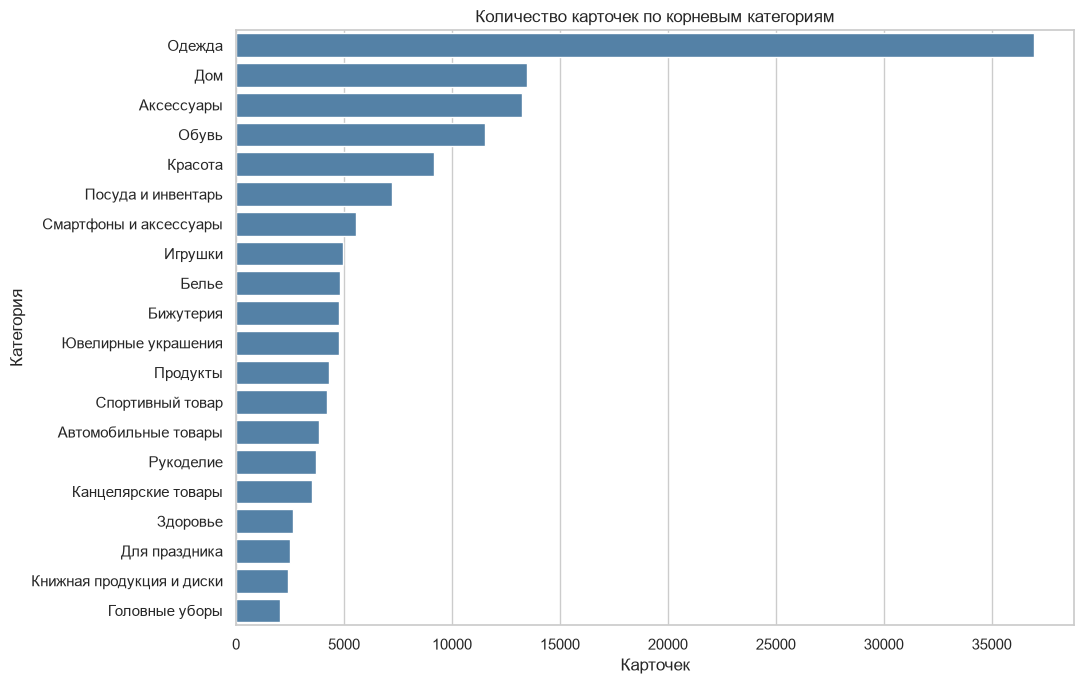

In [26]:
plot_data = root_counts.head(20).reset_index()
plt.figure(figsize=(11, 7))
sns.barplot(data=plot_data, x="cards", y="subj_root_name", color="steelblue")
plt.title("Количество карточек по корневым категориям")
plt.xlabel("Карточек")
plt.ylabel("Категория")
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / "categories.png", dpi=140)
plt.show()


**Категории.** В выгрузке 65 значений корневой категории и 3 234 предметные категории. Среди корневых значений есть пустая строка — восемь карточек; её не следует считать полноценным товарным доменом. Наиболее крупная категория — одежда: 36 965 карточек. В обуви 11 524 карточки. Для 820 предметных категорий представлено всего по одной-две карточки, поэтому единая оценка по всему каталогу скрывала бы сильную неоднородность данных.

Окончательный выбор домена ниже дополнительно опирается на покрытие обучающей разметкой. Популярность категории в каталоге сама по себе не гарантирует, что для неё достаточно оценённых запросов.


In [27]:
# Слова и символы позволяют оценить длину; лимит модели позже проверим токенизатором.
lengths = pd.DataFrame(index=df_raw.index)
for col in ["imt_name", "description"]:
    text = df_raw[col].fillna("").astype(str)
    lengths[col + "_chars"] = text.str.len()
    lengths[col + "_words"] = text.str.split().str.len()
display(lengths.describe(percentiles=[0.5, 0.9, 0.95, 0.99]).T)


,count,mean,std,min,50%,90%,95%,99%,max
imt_name_chars,200000.000,32.866,23.961,0.000,31.000,65.000,80.000,97.000,122.000
imt_name_words,200000.000,4.802,3.643,0.000,4.000,10.000,12.000,15.000,31.000
description_chars,200000.000,372.371,474.557,0.000,227.000,934.000,1082.000,2067.000,5000.000
description_words,200000.000,50.385,64.586,0.000,31.000,125.000,152.000,289.000,754.000


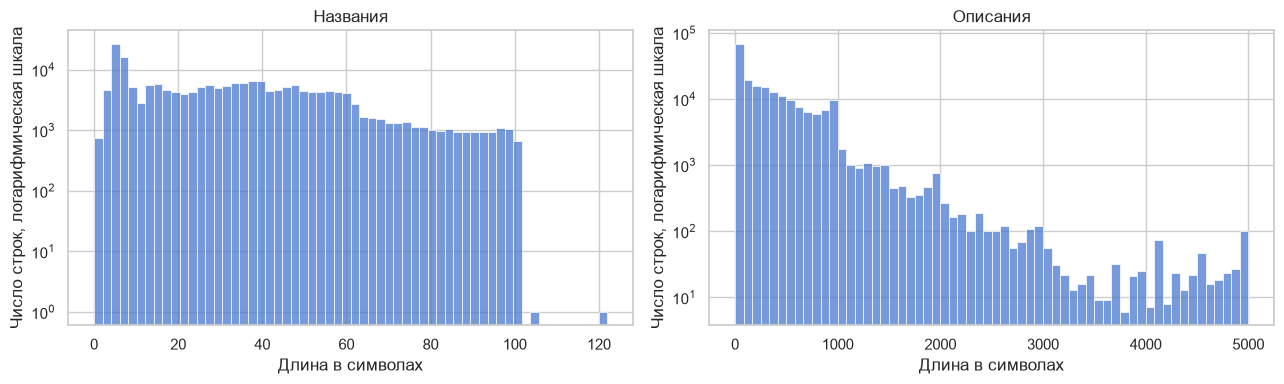

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, col in zip(axes, ["imt_name_chars", "description_chars"]):
    # Логарифмическая шкала числа наблюдений сохраняет видимость редких длинных текстов.
    sns.histplot(data=lengths, x=col, bins=60, ax=ax)
    ax.set_yscale("log")
    ax.set_title("Названия" if col == "imt_name_chars" else "Описания")
    ax.set_xlabel("Длина в символах")
    ax.set_ylabel("Число строк, логарифмическая шкала")
fig.tight_layout()
fig.savefig(ARTIFACTS_DIR / "text_lengths.png", dpi=140)
plt.show()


In [29]:
display(df_raw.loc[lengths["description_chars"].nlargest(5).index,
                   ["imt_id", "imt_name", "description"]])


imt_id                                                     imt_name  \
39185  10035242                        Платье женское "Gina" большие размеры   
39186  10035243                       Платье женское "Gwen", большие размеры   
39939  10035872               Джинсы женские большие размеры высокая посадка   
39940  10035873   Джинсы женские "Camilla", большие размеры, высокая посадка   
39942  10035875  Джинсы женские "Josephine", большие размеры,высокая посадка   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                        

**Длины текстов.** Медиана названия — 31 символ и четыре слова; медиана описания — 227 символов и 31 слово. У 99% строк описание не длиннее 2 067 символов, но максимум достигает 5 000 символов и 754 слов. Поэтому название удобно поставить в начало `product_text`, а описание использовать как источник назначения и характеристик.

Количество слов не равно количеству токенов модели. Решение о допустимой обрезке принимается ниже по токенизатору E5, отдельно для подготовленного каталога оценки. Логарифмическая шкала частот на графике позволяет видеть редкие длинные тексты без их удаления.


In [30]:
# Просмотр случайных карточек: HTML, реклама, артикулы, повторяющиеся описания.
sample_cards = df_raw.sample(min(25, len(df_raw)), random_state=SEED)
with pd.option_context("display.max_colwidth", 1500):
    display(sample_cards[["imt_id", "imt_name", "subj_name", "description",
                          "brand_name", "nm_colors_names"]])
sample_cards.to_csv(ARTIFACTS_DIR / "eda_sample_25.csv", index=False)


,imt_id,imt_name,subj_name,description,brand_name,nm_colors_names
119737,10108023,Набор гель-блестки для тела с кисточкой,Глиттеры,"Lucky набор гель-блестки д тела/лица х3 шт + кисточка, цвета: синий, серебро, пурпур, на блистере.",LUKKY,"глубокий пурпурный, синий"
72272,10064796,Пирсинг для пупка серебро 925 проба,Ювелирный пирсинг,"Изделие выполнено из серебра 925 пробы; покрытие: родирование; средний вес: 0,35 гр; длина: 1,5 см; ширина: 1 мм; диаметр: 2 мм. Ювелирное украшение имеет пробу, что подтверждает его подлинность. Приобретая данное изделие - вы получаете готовое решение для подарка. Значение веса в характеристиках является примерным и может незначительно отличаться от фактического.\n\nПирсинг Rich Line станет отличным подарком на любой праздник человеку, который носит такие украшения или любит экспериментировать со стилем. Размер пирсинга не надо подбирать, он универсален, поэтому вы всегда угадаете с подарком. У нас есть как крупные сережки для пирсинга с камнями, так и изящные серебряные изделия. Пирсинг изготовлен из серебра 925 пробы или серебра с позолотой, поэтому он не вызывает аллергии и не раздражает прокол. Моделей множество: пирсинг для брови, пирсинг для губ, пирсинг для носа, пирсинг для пупка, пирсинг для ушей. Есть модели как без замка, так и с винтовой застежкой.\n\nПодарок маме, подарок девушке, подарок любимой женщине, подарок бабушке, подарок подруге, подарок на день всех влюбленных (14 февраля), подарок для мамы, подарок для девушки, подарок на 8 марта, подарок на день рождения, подарок на др, подарок на день матери, подарок на годовщину, подарок на новый год, подарок коллеге, подарок корпоративный, красивый подарок, серебряный пирсинг, пирсинг из серебра, пирсинг под золото, пирсинг с позолотой, пирсинг женский, пирсинг женский серебро, пирсинг 925 серебро, дизайнерски...",RICH LINE,серебристый
158154,10147294,Чехол на Samsung Galaxy M21 / M30s / M31,Чехлы для телефонов,"Противоударный чехол отлично защищает смартфон при падении. Удобная подставка позволит комфортно просматривать видео. Бортик чехла выступает над дисплеем телефона, что позволит спокойно класть телефон вниз экраном.",Kupicase,оранжевый
65426,10058577,Набор стикеров Аниме Naruto (Наруто),Стикеры,"В набор входит 63 стикера. Стикеры можно клеить куда угодно, как на любую технику, так и на школьные принадлежности.",FANDOM,белый
30074,10027164,Контактные линзы Pure Vision 2 (6 линз) R 8.6 D -6.00,Контактные линзы,"В этих одномесячных линзах идеально сочетаются высокая четкость зрения и гарантированный комфорт. Они идеально корригируют зрение с утра до самого вечера: даже в темное время Вы сможете ясно видеть все вокруг, а изображение будет четким и контрастным, избавленным от ореолов и бликов. Контактные линзы PureVision 2 HD необычайно тонки - всего 0,07 мм, а их края имеют немного закругленную форму - за счет этого линзы совершенно не чувствуются на глазах и незаметны даже для Вас самих. Кислородопроницаемость PureVision 2 HD довольно высока - на протяжении 24 часов они обеспечивают свободный доступ кислорода к поверхности глаза, поэтому носить их чрезвычайно комфортно и удобно.",Bausch+Lomb,
23677,10021271,"Головка 1/2"" DR со вставкой TORX T70 длиной 100мм (AT-BS-31)",Головки торцевые,"Инструменты соответствуют высоким стандартам качества, поэтому подойдут как для использования на бытовом уровне, так и для применения в профессиональной сфере.\nИнструменты изготовлены из высококачественной хром-ванадиевой стали. Металлические части изготовлены методом горячей ковки, что придаёт им высокую прочность и долговечность. Финишное прочное хромированное покрытие защищает Инструмент от воздействия коррозии, делает его более износостойким и легко очищается от загрязнений. Финишная обработка двух типов (частичная полировка) головок придаёт им отличный внешний вид.",Airline,
134858,10126692,"Сумка для ноутбука 13.3"" с косметичкой",Сумки для ноутбуков,"В комплекте: Сумка для ноутбука + косметичка.\n\nРазмер 13.3 дюйма \nвнешний размер 35*26*3

In [31]:
has_html = df_raw["description"].fillna("").str.contains(r"<[^>]+>", regex=True)
print(f"Описания с HTML: {has_html.mean():.2%}")
nonempty_descriptions = df_raw.loc[~empty_text(df_raw["description"]), "description"]
display(nonempty_descriptions.value_counts().head(10).to_frame("Частота описания"))
print("Уникальных непустых брендов:",
      df_raw.loc[~empty_text(df_raw["brand_name"]), "brand_name"].nunique())


Описания с HTML: 0.01%


,Частота описания
description,
"Коврики изготовлены именно для Вашего автомобиля , полностью повторяют форму пола, на 100% защищая его от грязи. Не промокают. Европейский материалы. Максимальный комфорт и уют. Не промокают. Гарантия 2 года. Текстильные коврики не скользят по полу за счет штатных оригинальных креплений. Есть коврики на все модели.",218
Проект Автоистория - это модели автомобилей в масштабе по демократичным ценам. Продукция проходит обязательную сертификацию и соответствует ГОСТ 25779-90. Товарные знаки используются с разрешения правообладателей.,181
Гарантийный срок товара 30 дней.,166
"Не спешите писать негативный отзыв при следующих ситуациях, независящих от нас: 1. Доставка задержалась или качество обслуживания в пункте выдачи не оправдало Ваших ожиданий. В данном случае напишите в техподдержку для оперативного решения. 2. Товар пришел поврежденным. Вы вправе отказаться от покупки и/или оформить возврат по браку. Товар спишут и утилизируют за наши средства, несмотря на вину доставщика/курьера, а Вам вернут денежные средства. 3. Пришел абсолютно другой товар. Пересортица товаров может происходить на складе. К сожалению, мы никак не можем повлиять на работу отдельных сотрудников марткеплейса, как бы этого не хотели. В данном случае необходимо оформить возврат, написать в техподдержку. С уважением, Ваш kari.",152
"Полотенцесушитель водяной от производителя Терминус представляет собой оригинальную модификацию устройства форм-фактора ""Лесенка"". Конструкция устройства позволит разместить на нём большое количество вещей для просушки и придаст помещению элегантности, дополнив его стильным аксессуаром.",150
"Защищает от воздействия окружающей среды и одновременно является аксессуаром. Маска многоразовая, можно стирать. Не является медицинским изделием, ее рекомендуется носить поверх медицинской маски. Материал: полиэстер, хлопок.",148
"Очки для зрения женские являются неотъемлемой частью образа современной женщины. Наш магазин предлагает Вам легкие и стильные очки, которые помогут не только корректировать зрение, но и стать настоящим аксессуаром модного образа. Особенности данного товара включают в себя дизайн, который отличается изящностью и элегантностью. Легкая пластиковая оправа изготовлена из прочного материала, что обеспечивает комфортное ношение на протяжении всего дня. Очки корригирующие обеспечивают ясное и четкое видение, благодаря чему Вы сможете наслаждаться чтением или любыми другими ежедневными задачами. Мы предлагаем широкий ассортимент моделей и цветов, чтобы Вы смогли подобрать очки, которые будут соответствовать Вашему индивидуальному стилю и предпочтениям. Заказав очки для зрения в нашем интернет-магазине, Вы получите высококачественный продукт, который поможет Вам исправить зрение и стать еще красивее.",145
"Матовый силиконовый чехол TELEPRO Matte Silicone отличное дополнение к Вашему смартфону. Приятная на ощупь, нескользящая поверхность практична в использовании, она более устойчива к царапинам и потертостям и на ней не видны отпечатки пальцев. Подходит для беспроводной зарядки.",140
"Водяной полотенцесушитель Grota много лет пользуется застуженной популярностью. Он характеризуется исключительной надёжностью, которая гарантирует многолетнюю эксплуатацию полотенцесушителя, в течении которой у Вас не возникнет с ним малейших проблем. Радиатор сочетает исключительно высокие эксплуатационные и эстетические характеристики, что превращает его в идеальное дизайнерское дополнение ванной или другой комнаты.",140


Уникальных непустых брендов: 13318


In [32]:
# Простая оценка: точное вхождение хотя бы одного цвета в название.
# Склонения вроде «белый / белые» этот способ не учитывает.
def color_in_title(row):
    colors = [part.strip().casefold() for part in str(row["nm_colors_names"]).split(",")]
    title = str(row["imt_name"]).casefold()
    return any(color and re.search(r"(?<!\w)" + re.escape(color) + r"(?!\w)", title)
               for color in colors)

with_color = df_raw.loc[~empty_text(df_raw["nm_colors_names"])]
if len(with_color):
    print(f"Цвет явно присутствует в названии: {with_color.apply(color_in_title, axis=1).mean():.2%}")


Цвет явно присутствует в названии: 2.65%


**Качество текста, бренд и цвет.** Для просмотра выбраны 25 строк с фиксированным seed. В них встречаются полезные числовые характеристики и обозначения моделей, например размер сумки 13,3 дюйма и совместимость чехлов с моделями телефонов, а также рекламные формулировки. Поэтому очистка убирает HTML, управляющие символы и лишние пробелы, но сохраняет числа, дефисы и обозначения моделей. Массовое удаление «рекламных» слов без отдельной проверки не применяется, чтобы не потерять полезные признаки.

Повторяющиеся шаблонные описания присутствуют в показанной таблице частот: они добавляют неуникальный текст в TF-IDF и эмбеддинги E5. Агрессивное удаление таких фрагментов не применяется без отдельного анализа, поскольку вместе с шаблоном можно потерять полезные характеристики товара.

HTML найден примерно в 0,01% описаний. Непустых брендов — 13 318. Хотя бы один цвет из отдельного поля буквально встречается в названии у 2,65% строк с заполненным цветом. Проверка не учитывает склонения, поэтому это оценка точных совпадений, а не полного смыслового дублирования.

Отдельное поле `brand_name` не добавляется в семантический текст: это соответствует ответу наставника на Q&A (12:04–15:02). Для запросов с брендом планируется проверить лексический поиск по бренду или фильтрацию. Упоминания брендов, уже встречающиеся в названии и описании, автоматически не удаляются: такое требование в конспекте не зафиксировано. Цвет пока не включён в текст baseline; его использование остаётся отдельной гипотезой. Цвета вариантов сохраняются как атрибут, но объединение всех цветов карточки в один текст требует проверки.


In [33]:
# Обзор разметки train, без обращения к test.
print("Пар запрос — товар:", len(queries_train))
print("Уникальных запросов:", queries_train["query_id"].nunique())
print("Размеченных товаров:", queries_train["item_id"].nunique())
display(queries_train.groupby("query_id")["item_id"].nunique().describe())
display(queries_train["relevance"].value_counts().sort_index().to_frame("Число пар"))


Пар запрос — товар: 11453
Уникальных запросов: 700
Размеченных товаров: 2285


count   700.000
mean     16.361
std       5.424
min       1.000
25%      14.000
50%      16.000
75%      19.000
max      31.000
Name: item_id, dtype: float64

,Число пар
relevance,
1,9652
2,1101
3,700


In [34]:
# Варианты порога: 1 — любое соответствие; 2 — оценки 2–3; 3 — только оценка 3.
# Порог 2 предложен в шаблоне: считаем положительными оценки 2–3.
# Это исходное правило бинарных метрик; NDCG использует всю шкалу 0–3.
RELEVANCE_THRESHOLD = 2


In [35]:
positive_counts = queries_train.assign(
    relevant=queries_train["relevance"].ge(RELEVANCE_THRESHOLD)
).groupby("query_id")["relevant"].sum()
print("Запросов без релевантных товаров:", positive_counts.eq(0).sum())
display(queries_train[["query_id", "query_text"]].drop_duplicates().sample(
    min(15, queries_train["query_id"].nunique()), random_state=SEED
))


Запросов без релевантных товаров: 0


,query_id,query_text
2484,SYN_000210,топы cop copine
8139,SYN_000714,худи mego as
6376,SYN_000561,бриджи зуавы
2446,SYN_000206,кожаные мокасины
5214,SYN_000450,кожаные сабо с открытым мысом
3373,SYN_000286,классические джинсовые джинсы
3746,SYN_000318,шубы натуральные на пуговицах
4678,SYN_000401,тапочки asd
4852,SYN_000414,тапочки t taccardi
5737,SYN_000505,кигуруми londe


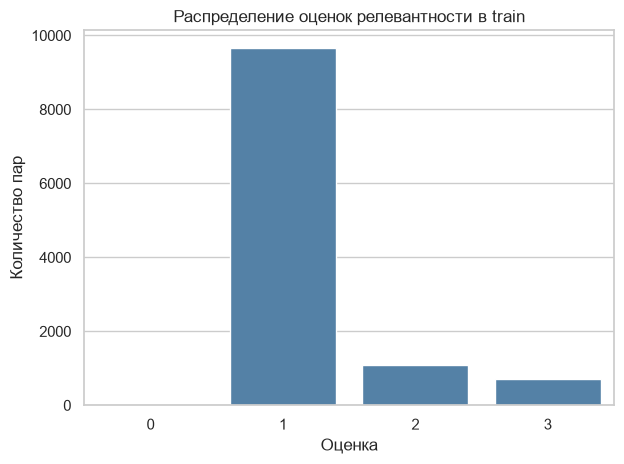

In [36]:
sns.countplot(data=queries_train, x="relevance", order=[0, 1, 2, 3], color="steelblue")
plt.title("Распределение оценок релевантности в train")
plt.xlabel("Оценка")
plt.ylabel("Количество пар")
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / "relevance.png", dpi=140)
plt.show()


**Разметка и порог релевантности.** Train содержит 700 запросов и 2 285 разных оценённых товаров. На запрос приходится в среднем 16,36 оценённых товаров, медиана — 16, диапазон — от одного до 31. Оценок 1 — 9 652, оценок 2 — 1 101, оценок 3 — 700; оценка 0 в train не встречается. Однако неразмеченные товары при расчёте метрик получают 0 по протоколу задания.

Для бинарных метрик выбран порог 2: положительными считаются оценки 2 и 3, а слабое соответствие с оценкой 1 не засчитывается. Такой порог предложен исходным шаблоном; это исходное правило оценки, а не результат подбора по метрикам. При этом NDCG сохраняет различие всех градаций и использует `2^relevance − 1`. При выбранном пороге нет запросов без релевантных товаров.

Среди примеров есть запросы по типу, материалу, фасону и бренду: «кожаные мокасины», «прямые жакеты», «пальто crockid». Это задача query-to-item. Запросы синтетические, поэтому полученные метрики нельзя напрямую переносить на реальные пользовательские логи.


---

## Неделя 2 — базовый пайплайн и оценка качества

**Цель:** оперевшись на результаты EDA, создать работающий поиск и получить первые метрики качества.

Прежде чем реализовывать семантический поиск, основанный на эмбеддингах, нужно проверить, как справляется более простая модель, опирающаяся на TF-IDF. Простая модель нужна как baseline, без этой точки отсчёта результат невозможно интерпретировать.


### 1. Подготовка данных


Реализуйте решения недели 1:

1. Отфильтруйте выбранные категории.
2. Дедуплицируйте строки по `imt_id`. Сформулируйте правило, по которому будете определять, какую строку оставить. К примеру, можете оставить строку с самым информативным описанием. Ответ обоснуйте.
3. Отбросьте карточки, у которых пусты одновременно и `imt_name`, и `description`.
4. Напишите функцию очистки текста.
5. Соберите единый текст карточек в отдельной колонке `product_text`.

In [37]:
# 25% групп запросов оставляем для сравнения методов, 75% — для обучения.
# Это стартовая пропорция, а не найденный оптимум. Альтернатива — 20% validation.
# Окончательное решение зависит от числа запросов в выбранных категориях.
VALIDATION_SIZE = 0.25

# Группируем одинаковые запросы с разным регистром и пробелами.
queries_train["query_group"] = normalize_queries(queries_train["query_text"])
query_groups = queries_train["query_group"].drop_duplicates().sort_values()
fit_groups, valid_groups = train_test_split(
    query_groups, test_size=VALIDATION_SIZE, random_state=SEED
)
train_fit = queries_train.loc[queries_train["query_group"].isin(fit_groups)].copy()
validation = queries_train.loc[queries_train["query_group"].isin(valid_groups)].copy()


In [38]:
print("Запросов train:", train_fit["query_id"].nunique())
print("Запросов validation:", validation["query_id"].nunique())
print("Общих текстов:", len(set(train_fit["query_group"]) & set(validation["query_group"])))
# У одного query_id должен быть один текст; покажем нарушения отдельно.
texts_per_id = queries_train.groupby("query_id")["query_group"].nunique()
display(texts_per_id[texts_per_id > 1].to_frame("Разных текстов на query_id"))
if (texts_per_id > 1).any():
    raise ValueError("У одного query_id несколько текстов. Исправьте разметку перед оценкой.")


Запросов train: 525
Запросов validation: 175
Общих текстов: 0


,Разных текстов на query_id
query_id,


**Разделение данных.** Из 700 запросов выделено 525 для обучающей части и 175 для validation. Разбиение выполнено по нормализованному тексту: регистр и повторные пробелы не должны позволить одному запросу оказаться в обеих частях. Общих нормализованных текстов нет; нескольких разных текстов у одного `query_id` также не обнаружено.

Доля validation 25% выбрана как начальный компромисс: остаются 175 запросов для сравнения методов и 525 для последующего обучения. Оптимальность этой доли не проверялась. На второй неделе E5 не дообучается; `train_fit` используется для выбора домена и ручных примеров. TF-IDF обучается на доступных текстах каталога, а не на ответах validation. Оценки финального test остаются отложенными; его ID и тексты используются только для проверки пересечения с train.


In [39]:
# Убираем HTML и лишние пробелы, но сохраняем числа, размеры, дефисы и названия моделей.
def clean_text(value):
    if pd.isna(value):
        return ""
    text = html.unescape(str(value))
    text = re.sub(r"<[^>]+>", " ", text)
    text = re.sub(r"[\x00-\x1f\x7f]", " ", text)
    return re.sub(r"\s+", " ", text).strip()


In [40]:
products = df_raw.drop_duplicates().copy()
for col in ["imt_name", "subj_name", "subj_root_name", "description",
            "brand_name", "nm_colors_names"]:
    products[col] = products[col].map(clean_text)

# Проверяем, встречаются ли разные корневые категории у одной карточки.
print("Карточек с конфликтом корневых категорий:",
      products.groupby("imt_id")["subj_root_name"].nunique().gt(1).sum())


Карточек с конфликтом корневых категорий: 0


In [41]:
# Варианты одной карточки могут отличаться цветом — сохраняем все цвета отдельно.
def collect_colors(values):
    return ", ".join(sorted({color.strip() for value in values
                              for color in value.split(",") if color.strip()}))


In [42]:
colors = products.groupby("imt_id")["nm_colors_names"].agg(collect_colors)
# Простое воспроизводимое правило: сначала непустое название, затем длинное описание,
# при равенстве — меньший nm_id. Длина — приближение информативности, проверяем по EDA.
products["has_name"] = products["imt_name"].ne("")
products["description_length"] = products["description"].str.len()
products = products.sort_values(
    ["imt_id", "has_name", "description_length", "nm_id"],
    ascending=[True, False, False, True], kind="stable",
).drop_duplicates("imt_id").copy()
products["nm_colors_names"] = products["imt_id"].map(colors)


In [43]:
# Выбор домена опирается только на обучающую часть разметки.
fit_categories = train_fit.loc[train_fit["relevance"].ge(RELEVANCE_THRESHOLD)].merge(
    products[["imt_id", "subj_root_name"]], left_on="item_id", right_on="imt_id",
    how="left", validate="many_to_one",
)


In [44]:
category_support = fit_categories.groupby("subj_root_name")["query_id"].nunique()
category_support = category_support.drop(index="", errors="ignore").sort_values(ascending=False)
display(category_support.to_frame("Положительных запросов в train_fit"))


,Положительных запросов в train_fit
subj_root_name,
Одежда,379
Обувь,146


In [45]:
# В задании рекомендован MVP на 1–3 категориях. Здесь выбираем до трёх по покрытию train.
# Выбираем по числу уникальных train-запросов с оценками 2–3, чтобы хватало разметки.
# Ограничение размеченными категориями подтверждено на Q&A (09:15–09:45).
# Альтернатива после EDA — явный список: selected_roots = ["Обувь", "Одежда"]
selected_roots = category_support.head(3).index.tolist()
print("Категории MVP:", selected_roots)


Категории MVP: ['Одежда', 'Обувь']


**Выбор домена.** Положительные пары в `train_fit` относятся к двум корневым категориям: 379 запросов связаны с одеждой и 146 — с обувью. Поэтому фактически выбраны **«Одежда» и «Обувь»**, хотя код допускает до трёх категорий. Это соответствует ответу наставника на Q&A (09:15–09:45): MVP ограничивается категориями с проверенной разметкой. Данные test для выбора не использовались.


In [46]:
# Сохраняем ID домена до отсева пустых карточек, чтобы показать потери в оценке.
domain_ids = set(products.loc[products["subj_root_name"].isin(selected_roots), "imt_id"])
products = products.loc[products["imt_id"].isin(domain_ids)].copy()
empty_cards = products["imt_name"].eq("") & products["description"].eq("")
print("Удалено карточек без названия и описания:", empty_cards.sum())
products = products.loc[~empty_cards].copy()
products["missing_description"] = products["description"].eq("")


Удалено карточек без названия и описания: 113


In [47]:
# Три осмысленных шаблона; основной включает назначение из описания.
products["text_name"] = products["imt_name"].where(products["has_name"], products["subj_name"])
products["text_short"] = (products["imt_name"] + ". " + products["subj_name"]).str.strip(". ")
products["product_text"] = (products["text_short"] + ". " + products["description"]).str.strip(". ")
# Для редких карточек без названия и категории короткий шаблон берёт описание.
for col in ["text_name", "text_short"]:
    products[col] = products[col].where(products[col].ne(""), products["description"])
products = products.sort_values("imt_id").reset_index(drop=True)
products.to_parquet(ARTIFACTS_DIR / "products_prepared.parquet", index=False)
display(products[["imt_id", "text_name", "text_short", "product_text"]].head())


,imt_id,text_name,text_short,product_text
0,100032,Платье,Платье. Платья,Платье. Платья
1,100033,Куртка,Куртка. Куртки,Куртка. Куртки
2,100035,Сандалии,Сандалии. Сандалии,Сандалии. Сандалии
3,100037,Ботинки,Ботинки. Ботинки,Ботинки. Ботинки
4,100083,Сандалии,Сандалии. Сандалии,Сандалии. Сандалии


**Дедупликация и текст карточки.** При выборе строки для одного `imt_id` сначала сохраняется вариант с непустым названием, затем с наиболее длинным описанием, а при равенстве — с меньшим `nm_id`. Это простое воспроизводимое правило: название задаёт тип товара, длина описания приближённо отражает объём доступных характеристик. Длина не гарантирует полезность текста, поэтому длинные описания дополнительно просмотрены в EDA. Конфликтов корневой категории внутри карточки не найдено.

Удалены 113 карточек без названия и описания. После подготовки в двух категориях осталось 48 376 карточек. Карточки с названием, но без описания, сохранены.

Подготовлены три варианта текста: название; название с предметной категорией; название, категория и описание. Для базового сравнения выбран третий: он сохраняет сведения о назначении и свойствах, которых может не быть в коротком названии. Это соответствует ответу наставника (10:46–12:03): имеющееся описание нужно использовать, а длинные тексты — сокращать. Поля разделены точкой, пропуски не превращаются в строки `nan` или `None`. Пять показанных примеров иллюстрируют в том числе корректное поведение при пустом описании. Колонки без описания сохранены как технические заготовки и не используются в базовом поиске; следующий эксперимент должен сравнивать способы сокращения описания, а не полностью исключать его.


### Каталог для поиска и оценки

1. Посчитайте метрику при поиске по всему отфильтрованному каталогу. Например, вычислите NDCG@10 лексическим поиском на 100 запросах.
2. Выведите топ-10 для одного запроса и отметьте, какие товары есть в разметке, а каких нет. Выясните, в чём проблема.
3. Ограничьте каталог оценки пулом асессоров: возьмите из `wb_products_dedup.parquet` только список `imt_id` и оставьте в своём подготовленном каталоге пересечение с ним. Тексты и все признаки — ваши, из шага 1.
4. Пересчитайте метрику и сравните результаты.
5. Посмотрите на распределение `relevance` и число оценённых товаров на запрос. Проверьте, у всех ли запросов есть товары с `relevance` ≥ 2.

In [48]:
# Служебный файл используется только как список ID, тексты остаются нашими.
assessed_ids = set(pd.read_parquet(ASSESSED_POOL_PATH, columns=["imt_id"])["imt_id"])
catalog = products.loc[products["imt_id"].isin(assessed_ids)].reset_index(drop=True)
catalog.to_parquet(ARTIFACTS_DIR / "catalog_eval.parquet", index=False)
print("Карточек в полном каталоге выбранных категорий:", len(products))
print("Карточек в каталоге оценки:", len(catalog))
print("ID из пула, отсутствующих в raw:", len(assessed_ids - set(df_raw["imt_id"])))


Карточек в полном каталоге выбранных категорий: 48376
Карточек в каталоге оценки: 4256
ID из пула, отсутствующих в raw: 0


In [49]:
def scope_queries(frame):
    # Берём запросы, у которых есть хотя бы один размеченный товар выбранного домена.
    # Положительную оценку не требуем: запросы без попаданий не скрываем.
    ids = frame.loc[frame["item_id"].isin(domain_ids), "query_id"].unique()
    scoped = frame.loc[frame["query_id"].isin(ids)].copy()
    in_catalog = scoped["item_id"].isin(catalog["imt_id"])
    positive = scoped["relevance"].ge(RELEVANCE_THRESHOLD)
    print("Запросов до / после выбора домена:", frame["query_id"].nunique(), len(ids))
    print("Размеченных положительных пар вне каталога оценки:", (positive & ~in_catalog).sum())
    # Метрики относятся к ограниченному каталогу, поэтому знаменатель Recall и IDCG
    # строим по доступным товарам. Потери положительных пар показаны выше отдельно.
    qrels = scoped.loc[in_catalog].copy()
    query_list = scoped[["query_id", "query_text"]].drop_duplicates()
    positive_ids = set(qrels.loc[qrels["relevance"].ge(RELEVANCE_THRESHOLD), "query_id"])
    print("Запросов без доступных релевантных товаров:",
          len(set(query_list["query_id"]) - positive_ids))
    return query_list, qrels


In [50]:
valid_queries, valid_qrels = scope_queries(validation)
valid_queries.to_csv(ARTIFACTS_DIR / "validation_queries.csv", index=False)
valid_qrels.to_parquet(ARTIFACTS_DIR / "validation_qrels.parquet", index=False)
# Сравнение полного каталога и пула будет ниже, после определения метрик.


Запросов до / после выбора домена: 175 175
Размеченных положительных пар вне каталога оценки: 0
Запросов без доступных релевантных товаров: 0


**Каталог и golden-сет.** Из 48 376 подготовленных карточек выделен общий пул оценки — 4 256 ID из `wb_products_dedup.parquet`. Все ID пула найдены в raw-каталоге. Тексты и признаки сформированы из raw, а служебный файл задаёт только множество кандидатов. Ограничение выдачи и расчёта метрик этим пулом прямо подтверждено наставником на Q&A (10:00–10:45).

После ограничения домена сохранены все 175 validation-запросов; положительных пар вне каталога оценки нет, запросов без доступного релевантного товара тоже нет. Таким образом, в этом запуске фильтрация не уменьшила число положительных validation-пар. Поиск каждого метода идёт по всем 4 256 карточкам, а не только по оценённым товарам конкретного запроса. Один и тот же golden-сет используется для обоих методов.


### 2. Модели поиска

Реализуйте два поисковых движка с одинаковым интерфейсом. Это позволит прогнать оба через одну функцию оценки:

In [51]:
# Общая сортировка для всех методов. При одинаковом score сохраняем порядок imt_id.
def top_items(frame, scores, top_k=10):
    if top_k < 1:
        raise ValueError("top_k должен быть положительным")
    order = np.argsort(-np.asarray(scores), kind="stable")[:top_k]
    result = frame.iloc[order][["imt_id", "imt_name", "subj_name"]].copy()
    result["score"] = np.asarray(scores)[order]
    return result.reset_index(drop=True)


Реализуйте лексический baseline на TF-IDF:

In [52]:
# TF-IDF обучается на каталоге: тексты товаров доступны до поступления запросов.
# Векторизатор не обучается на test-запросах или их оценках.
def build_lexical(frame, text_column="product_text", analyzer="word", ngram_range=(1, 2)):
    vectorizer = TfidfVectorizer(
        lowercase=True, analyzer=analyzer, ngram_range=ngram_range,
        min_df=1, sublinear_tf=True, max_features=100_000, dtype=np.float32,
    )
    matrix = vectorizer.fit_transform(frame[text_column])

    def score_query(query):
        vector = vectorizer.transform([clean_text(query)])
        return (matrix @ vector.T).toarray().ravel()

    return score_query, vectorizer, matrix


In [53]:
lexical_scores, _, tfidf_matrix = build_lexical(catalog)


In [54]:
def search_lexical(query: str, top_k: int = 10) -> pd.DataFrame:
    return top_items(catalog, lexical_scores(query), top_k)


print("Размер TF-IDF матрицы:", tfidf_matrix.shape)


Размер TF-IDF матрицы: (4256, 100000)


**Лексический baseline.** TF-IDF выбран как простая воспроизводимая точка отсчёта. Униграммы и биграммы `(1, 2)` позволяют учитывать отдельные слова и сочетания вроде «зимние сапоги». Ограничение словаря в 100 000 признаков сдерживает размер матрицы; фактическая матрица имеет форму `(4256, 100000)`, то есть лимит достигнут. Это стартовое ограничение ресурсов, а не найденный оптимум.

`min_df=1` сохраняет редкие слова, которые могут быть значимыми названиями и артикулами. `sublinear_tf=True` уменьшает влияние повторения одного слова в описании. Значения `float32` сокращают память матрицы. Запрос проходит ту же очистку, а векторизатор приводит регистр и нормализует векторы, поэтому скалярное произведение соответствует косинусному сходству. При равных оценках сохраняется порядок по `imt_id`, чтобы выдача была воспроизводимой.


Реализуйте семантический поиск:

In [55]:
# Модели E5: small — 384, base — 768, large — 1024 компоненты вектора.
# Страницы: https://huggingface.co/intfloat/multilingual-e5-small
#          https://huggingface.co/intfloat/multilingual-e5-base
#          https://huggingface.co/intfloat/multilingual-e5-large
# Для базового семантического поиска выбрана multilingual-e5-base.
# Качество на нашем каталоге сравним с TF-IDF и другими вариантами поиска.
# Для замены на другое семейство проверяем его правила подготовки запросов.
MODEL_NAME = "intfloat/multilingual-e5-base"
# 32 — стартовый размер батча, а не результат замера GPU.
# Если не хватает памяти — 16; при запасе можно сравнить скорость с 64.
BATCH_SIZE = 32
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Устройство:", DEVICE)


Устройство: cuda


In [56]:
# При первом запуске веса модели будут скачаны с Hugging Face.
# Правила E5: query: для запросов, passage: для товаров, нормализация векторов.
# Документация: https://huggingface.co/intfloat/multilingual-e5-base
model = SentenceTransformer(MODEL_NAME, device=DEVICE)
model.max_seq_length = 512
MODEL_REVISION = getattr(model[0].auto_model.config, "_commit_hash", None) or "unknown"


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 7644.10it/s]


In [57]:
def encode_products(texts):
    return model.encode(
        ["passage: " + text for text in texts], batch_size=BATCH_SIZE,
        normalize_embeddings=True, show_progress_bar=True, convert_to_numpy=True,
    )


In [58]:
def encode_query(query):
    return model.encode(
        ["query: " + clean_text(query)], normalize_embeddings=True,
        show_progress_bar=False, convert_to_numpy=True,
    )[0]


In [59]:
product_embeddings = encode_products(catalog["product_text"].tolist())
np.save(ARTIFACTS_DIR / "product_embeddings.npy", product_embeddings)
np.save(ARTIFACTS_DIR / "embedding_item_ids.npy", catalog["imt_id"].to_numpy())


Batches: 100%|██████████| 133/133 [00:03<00:00, 37.40it/s] 


In [60]:
def semantic_scores(query):
    # Для небольшого пула достаточно точного поиска по косинусной близости.
    return product_embeddings @ encode_query(query)


def search_semantic(query: str, top_k: int = 10) -> pd.DataFrame:
    return top_items(catalog, semantic_scores(query), top_k)


print("Размер матрицы эмбеддингов:", product_embeddings.shape)


Размер матрицы эмбеддингов: (4256, 768)


In [61]:
# Проверяем реальную длину в токенах до обрезки, а не заменяем её числом слов.
token_lengths = []
for start in range(0, len(catalog), BATCH_SIZE):
    texts = ["passage: " + text for text in catalog["product_text"].iloc[start:start + BATCH_SIZE]]
    tokens = model.tokenizer(texts, truncation=False, padding=False)
    token_lengths.extend(len(ids) for ids in tokens["input_ids"])
token_lengths = pd.Series(token_lengths)
display(token_lengths.describe(percentiles=[0.5, 0.9, 0.95, 0.99]))
print(f"Доля обрезаемых текстов: {token_lengths.gt(model.max_seq_length).mean():.2%}")

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (549 > 512). Running this sequence through the model will result in indexing errors


count   4256.000
mean     107.644
std      108.948
min        8.000
50%       78.000
90%      247.500
95%      304.000
99%      533.700
max     1135.000
dtype: float64

Доля обрезаемых текстов: 1.25%


**Семантическая модель.** Для первого сравнения выбрана `intfloat/multilingual-e5-base`: мультиязычная модель для текстового поиска. Её эмбеддинги имеют 768 компонент, что подтверждено матрицей `(4256, 768)`. Это выбранная стартовая модель; сравнением с TF-IDF нельзя доказать, что она лучше других моделей эмбеддингов.

Товары кодируются с префиксом `passage:`, запросы — с `query:` согласно правилам E5; для обеих сторон используется одна модель и L2-нормализация. Поэтому скалярное произведение сопоставляет их в одном пространстве по косинусной близости. Для 4 256 кандидатов используется точный перебор: отдельная система приближённого поиска пока не нужна. Эмбеддинги и порядок ID сохраняются в `.npy`; текущая ячейка всё ещё пересчитывает их при повторном запуске.

`BATCH_SIZE=32` — начальное значение для расчёта эмбеддингов на доступном GPU, а не результат подбора скорости. В сохранённом запуске вычисления прошли на CUDA. Медиана длины подготовленного текста — 78 токенов, 95-й перцентиль — 304, максимум — 1 135. При лимите 512 токенов обрезаются 1,25% карточек. Для baseline это небольшой охват проблемы, но потеря конца описания может объяснять ошибки на отдельных товарах. Название и категория поставлены в начало текста, чтобы сохранить их при обрезке.

Q&A (10:46–12:03) подтверждает необходимость сокращения длинных описаний. Усечение входа до 512 токенов оставлено как базовое правило; на следующем этапе нужно сравнить его с отбором предложений или значимых фрагментов описания.


Прогоните 3–5 запросов вручную и сравните выдачу обоих подходов. Это самый простой способ поймать грубые ошибки до подсчёта метрик.

In [62]:
# Первичная ручная проверка на запросах обучающей части.
manual_queries = train_fit.loc[train_fit["item_id"].isin(catalog["imt_id"]),
                               ["query_id", "query_text"]].drop_duplicates()
for row in manual_queries.sample(min(5, len(manual_queries)), random_state=SEED).itertuples():
    print("Запрос:", row.query_text)
    print("TF-IDF:")
    display(search_lexical(row.query_text, 5))
    print("Семантический поиск:")
    display(search_semantic(row.query_text, 5))

Запрос: шелковые топы
TF-IDF:


,imt_id,imt_name,subj_name,score
0,10016977,Топы,Топы,0.716
1,101146,Топ,Топы,0.542
2,10042858,Майка,Топы,0.471
3,10150664,Топ - CINTIA,Топы,0.455
4,10022566,Топ женский,Топы,0.384


Семантический поиск:


,imt_id,imt_name,subj_name,score
0,10031321,Топ шелковый бельевой под пиджак,Топы,0.881
1,10179763,Топ на тонких бретельках/шелковый (вискоза 100%),Топы,0.871
2,10103803,Топ женский,Топы,0.865
3,10016977,Топы,Топы,0.842
4,10010349,Топ,Топы,0.840


Запрос: приталенные хлопковые жакеты
TF-IDF:


...

,imt_id,imt_name,subj_name,score
0,10043424,Комбинезон защитный одноразовый,Комбинезоны,0.896
1,10016095,Комбинезон из однотонной ткани,Комбинезоны,0.863
2,10024554,Комбинезон,Комбинезоны,0.850
3,10013875,Комбинезон,Комбинезоны,0.850
4,10108993,Комбинезон,Комбинезоны,0.849


Запрос: кожаные сандалии
TF-IDF:


,imt_id,imt_name,subj_name,score
0,100464,Сандалии,Сандалии,0.377
1,10068273,Сандалии / Туфли / Босоножки,Сандалии,0.251
2,1003230,Сандалии,Туфли,0.244
3,10019008,Сандалии,Босоножки,0.243
4,10171853,Сандалии / Женские / Искусственная кожа,Сандалии,0.217


Семантический поиск:


,imt_id,imt_name,subj_name,score
0,10013140,Босоножки кожа Турция,Сандалии,0.881
1,10045302,Сандалии,Сандалии,0.864
2,10020938,Сандалии,Сандалии,0.860
3,10012463,Сандалии для мальчика кожаные м.01280/5С,Сандалии,0.859
4,10160889,Сандалии,Туфли,0.859


**Ручное сравнение выдачи.** Проверены пять запросов обучающей части, для каждого показан top-5 обоих методов. Для «комбинезоны защитный одноразовый» оба метода ставят на первое место карточку с таким названием: на точном совпадении TF-IDF уже решает задачу.

Для «шелковые топы» семантический поиск поднимает карточку «Топ шелковый бельевой под пиджак», а для «кожаные сандалии» — «Босоножки кожа Турция». Это иллюстрирует потенциальную пользу сопоставления характеристик и близких названий. Одновременно «шелковый» товар с указанием «вискоза 100%» показывает, что сходство текста не гарантирует совпадения материала. Для «приталенные хлопковые жакеты» коротких названий в выдаче недостаточно, чтобы подтвердить оба атрибута: нужны полные карточки и оценки.

У TF-IDF по запросу «кожаные сандалии» в top-5 присутствует карточка с искусственной кожей. Это возможное расхождение с намерением пользователя. Такие наблюдения рассматриваются как примеры для анализа, а не как замена оценкам релевантности.


### 3. Оценка качества решений

Реализуйте метрики Precision@K, Recall@K, MRR, NDCG@K, HitRate@K.

Три ключевые особенности, которые надо учесть при расчёте:

1. Порог бинаризации. Precision@K, Recall@K, MRR, HitRate@K бинарны, а шкала `relevance` — от `0` до `3`. С какой оценки товар считается релевантным? Вынесите порог в параметр, а не константу внутри функции.
2. NDCG считайте по полной шкале 0–3 (`gain = 2^rel - 1`), а не по бинаризованной, иначе теряется смысл градуированной разметки.
3. Неразмеченные товары в выдаче трактуйте как нерелевантные (`relevance_map.get(item_id, 0)`).

Выводы запишите в Markdown-ячейке и рабочем файле Markdown.

In [63]:
# check_mlflow.py ожидает Precision@5, Recall@10 и NDCG@10.
# Поэтому смотрим точность первых пяти товаров и качество первых десяти.
# Это исходный протокол задания; K не подбираем по лучшему результату.
K_VALUES = (5, 10)


In [64]:
# Неразмеченным товарам присваиваем 0 в соответствии с протоколом задания.
# Это условность оценки, а не доказательство нерелевантности такого товара.
def query_metrics(ranked_ids, relevance_map, threshold=RELEVANCE_THRESHOLD):
    grades = np.array([relevance_map.get(item, 0) for item in ranked_ids], dtype=float)
    binary = grades >= threshold
    total_relevant = sum(rel >= threshold for rel in relevance_map.values())
    metrics = {}
    for k in K_VALUES:
        hits = int(binary[:k].sum())
        metrics[f"precision_at_{k}"] = hits / k
        metrics[f"recall_at_{k}"] = hits / total_relevant if total_relevant else 0.0
        metrics[f"hit_rate_at_{k}"] = float(hits > 0)
        gains = 2 ** grades[:k] - 1
        dcg = np.sum(gains / np.log2(np.arange(2, len(gains) + 2)))
        ideal = np.array(sorted(relevance_map.values(), reverse=True)[:k], dtype=float)
        idcg = np.sum((2 ** ideal - 1) / np.log2(np.arange(2, len(ideal) + 2)))
        metrics[f"ndcg_at_{k}"] = float(dcg / idcg) if idcg else 0.0
    # Здесь MRR без усечения: передаём ранжирование всего каталога.
    positions = np.flatnonzero(binary)
    metrics["mrr"] = 1.0 / (positions[0] + 1) if len(positions) else 0.0
    return metrics


In [65]:
def evaluate(score_function, frame, query_list, qrels):
    relevance_maps = {qid: dict(zip(group["item_id"], group["relevance"]))
                      for qid, group in qrels.groupby("query_id")}
    rows = []
    for query in query_list.itertuples(index=False):
        start = perf_counter()
        scores = score_function(query.query_text)
        order = np.argsort(-scores, kind="stable")
        elapsed = (perf_counter() - start) * 1000
        ranked_ids = frame["imt_id"].iloc[order].tolist()
        values = query_metrics(ranked_ids, relevance_maps.get(query.query_id, {}))
        rows.append({"query_id": query.query_id, "query_text": query.query_text,
                     **values, "latency_ms": elapsed})
    details = pd.DataFrame(rows)
    summary = details.drop(columns=["query_id", "query_text"]).mean().to_dict()
    return summary, details


**Правила расчёта метрик.** Используются K = 5 и 10: первые пять позиций характеризуют начало выдачи, первые десять — более широкий результат поиска. Эти значения также согласуются с `check_mlflow.py`. Порог бинаризации равен 2, а NDCG считается по исходным оценкам 0–3. MRR вычисляется по полному ранжированию каталога, без усечения на десятой позиции.

Метрики сначала считаются для каждого запроса, затем усредняются с одинаковым весом запросов. Неразмеченный товар получает оценку 0. Recall и идеальное ранжирование для NDCG строятся по разметке общего каталога оценки. Если у запроса нет релевантных товаров или положительного IDCG, соответствующая метрика принимается равной нулю; в текущем validation нет запросов без релевантных товаров.


In [66]:
# Учебный опыт: одинаковые запросы и оценки, но разные каталоги кандидатов.
# Используем один TF-IDF, обученный на полном каталоге, чтобы менять только пул поиска.
# Для этого опыта нужна только функция поиска; матрица хранится внутри неё.
full_scores, _, _ = build_lexical(products)
pool_mask = products["imt_id"].isin(catalog["imt_id"]).to_numpy()


In [67]:
def restricted_full_scores(query):
    return full_scores(query)[pool_mask]


In [68]:
comparison_queries = valid_queries.sample(min(100, len(valid_queries)), random_state=SEED)
full_summary, _ = evaluate(full_scores, products, comparison_queries, valid_qrels)
pool_summary, _ = evaluate(restricted_full_scores, catalog, comparison_queries, valid_qrels)
display(pd.DataFrame([full_summary, pool_summary], index=["Полный каталог", "Пул оценки"]))


,precision_at_5,recall_at_5,hit_rate_at_5,ndcg_at_5,precision_at_10,recall_at_10,hit_rate_at_10,ndcg_at_10,mrr,latency_ms
Полный каталог,0.018,0.061,0.090,0.081,0.009,0.061,0.090,0.081,0.058,2.508
Пул оценки,0.058,0.150,0.220,0.350,0.070,0.316,0.440,0.436,0.179,2.323


In [69]:
example = comparison_queries.iloc[0]
example_relevance = valid_qrels.loc[valid_qrels["query_id"].eq(example["query_id"])].set_index("item_id")["relevance"]
example_top = top_items(products, full_scores(example["query_text"]), 10)
example_top["есть_разметка"] = example_top["imt_id"].isin(example_relevance.index)
example_top["relevance"] = example_top["imt_id"].map(example_relevance)
print("Запрос:", example["query_text"])
display(example_top)
print("NaN означает отсутствие оценки. Такие товары при расчёте метрик получают 0.")


Запрос: блузки rita pfeffinger


,imt_id,imt_name,subj_name,score,есть_разметка,relevance
0,10170287,"Легинсы,черный,s",Леггинсы,0.314,False,NaN
1,10170288,"Пуловер,бежевый,52",Пуловеры,0.254,False,NaN
2,10170273,"Блуза,розовый,56",Блузки,0.252,False,NaN
3,10145702,"Блуза,розовый,54",Блузки,0.239,False,NaN
4,10170279,"Блузка женская, кофта женская",Блузки,0.234,False,NaN
5,10145740,"Пуловер,серебристо-серый,46",Пуловеры,0.233,False,NaN
6,10170276,"Блузка женская, кофта женская",Блузки,0.228,False,NaN
7,10170278,"Блузка женская, кофта женская",Блузки,0.228,False,NaN
8,10145732,"Брюки,черный,56",Брюки,0.222,False,NaN
9,10100454,Платье,Блузки,0.214,False,NaN


NaN означает отсутствие оценки. Такие товары при расчёте метрик получают 0.


**Влияние пула оценки.** На одних и тех же 100 validation-запросах NDCG@10 лексического поиска составляет 0,081 по полному отфильтрованному каталогу и 0,436 по пулу оценки. Recall@10 меняется с 0,061 до 0,316. В этом опыте используется один TF-IDF, обученный на полном каталоге, поэтому сравнивается именно состав кандидатов.

Для запроса «блузки rita pfeffinger» все десять товаров полной выдачи отсутствуют в разметке этого запроса. Это не означает, что все они подходят: на первых позициях есть леггинсы и пуловер. Но оно показывает, что по имеющейся разметке нельзя надёжно судить обо всём каталоге.

Рост метрик после ограничения кандидатов не является улучшением модели. Это изменение условий оценки. Поэтому основные методы далее сравниваются на одном пуле из 4 256 карточек. Значения этого опыта нельзя напрямую смешивать с основной таблицей: здесь 100 запросов и TF-IDF полного каталога, а в основном сравнении — 175 запросов и TF-IDF пула.


In [70]:
# Настраиваем MLflow до экспериментов. По умолчанию всё хранится локально.
tracking_uri = os.getenv("MLFLOW_TRACKING_URI", "sqlite:///mlflow.db")
if tracking_uri == "sqlite:///mlflow.db":
    tracking_uri = "sqlite:///" + (PROJECT_DIR / "mlflow.db").as_posix()
mlflow.set_tracking_uri(tracking_uri)
EXPERIMENT_NAME = "wb-semantic-search"
if mlflow.get_experiment_by_name(EXPERIMENT_NAME) is None:
    if tracking_uri.startswith(("http://", "https://")):
        mlflow.create_experiment(EXPERIMENT_NAME)
    else:
        mlflow.create_experiment(
            EXPERIMENT_NAME, artifact_location=(PROJECT_DIR / "mlartifacts").as_uri()
        )
mlflow.set_experiment(EXPERIMENT_NAME)


<Experiment: artifact_location='file:///home/danat/personal_projects/final_project_dse/ProjectMonth/mlartifacts', creation_time=1790087889628, effective_trace_archival_retention=None, experiment_id='1', last_update_time=1790087889628, lifecycle_stage='active', name='wb-semantic-search', tags={}, trace_location=None, workspace='default'>

In [71]:
results = []
# Словари сохраняют результаты, функции поиска и параметры для продолжения
# в semantic_search_project_week3.ipynb после его переноса обратно.
per_query_results = {}
search_methods = {}
method_configs = {}


In [72]:
def evaluate_and_log(name, score_function, text_template, hypothesis, **extra_params):
    # Замеряем поиск без загрузки модели и построения индекса.
    params = {
        "method": name, "eval_split": "validation", "catalog_size": len(catalog),
        "relevance_threshold": RELEVANCE_THRESHOLD, "seed": SEED,
        "text_template": text_template, "k_values": ",".join(map(str, K_VALUES)),
        "model": MODEL_NAME if name.startswith(("semantic", "hybrid")) else "tfidf",
        "model_revision": MODEL_REVISION,
        "categories": ", ".join(selected_roots), "validation_size": VALIDATION_SIZE,
        "max_seq_length": model.max_seq_length, "device": DEVICE,
        "batch_size": BATCH_SIZE, "mrr_scope": "full_catalog",
        **extra_params,
    }
    with mlflow.start_run(run_name=name):
        mlflow.log_params(params)
        mlflow.set_tag("hypothesis", hypothesis)
        summary, details = evaluate(score_function, catalog, valid_queries, valid_qrels)
        mlflow.log_metrics(summary)
        details_path = ARTIFACTS_DIR / f"{name}_per_query.csv"
        details.to_csv(details_path, index=False)
        mlflow.log_artifact(str(details_path))
        mlflow.log_artifact(str(ARTIFACTS_DIR / "validation_queries.csv"))
        mlflow.log_artifact(str(ARTIFACTS_DIR / "validation_qrels.parquet"))
        mlflow.log_artifact(str(ARTIFACTS_DIR / "catalog_eval.parquet"))
        mlflow.log_dict(params, "config.json")
        mlflow.log_dict(summary, "metrics.json")
        for plot in ARTIFACTS_DIR.glob("*.png"):
            mlflow.log_artifact(str(plot), artifact_path="plots")
    # Повторный запуск ячейки заменяет строку в текущей сводке.
    results[:] = [row for row in results if row["method"] != name]
    results.append({"method": name, **summary})
    per_query_results[name] = details
    search_methods[name] = score_function
    method_configs[name] = params
    display(pd.DataFrame([{"method": name, **summary}]))


In [73]:
evaluate_and_log("lexical_base", lexical_scores, "product_text", "Лексический baseline",
               analyzer="word", ngram_range="1,2", max_features=100000, sublinear_tf=True)


,method,precision_at_5,recall_at_5,hit_rate_at_5,ndcg_at_5,precision_at_10,recall_at_10,hit_rate_at_10,ndcg_at_10,mrr,latency_ms
0,lexical_base,0.066,0.167,0.234,0.352,0.067,0.327,0.434,0.432,0.169,0.752


In [74]:
evaluate_and_log("semantic_base", semantic_scores, "product_text", "Семантический baseline")


,method,precision_at_5,recall_at_5,hit_rate_at_5,ndcg_at_5,precision_at_10,recall_at_10,hit_rate_at_10,ndcg_at_10,mrr,latency_ms
0,semantic_base,0.197,0.477,0.617,0.472,0.128,0.585,0.691,0.489,0.511,7.365


In [75]:
baseline_table = pd.DataFrame(results)
baseline_table.to_csv(ARTIFACTS_DIR / "baseline_metrics.csv", index=False)
# Копия в корне репозитория обновляется вместе с результатами запуска.
baseline_table.to_csv(PROJECT_DIR / "baseline_metrics.csv", index=False)
display(baseline_table)


,method,precision_at_5,recall_at_5,hit_rate_at_5,ndcg_at_5,precision_at_10,recall_at_10,hit_rate_at_10,ndcg_at_10,mrr,latency_ms
0,lexical_base,0.066,0.167,0.234,0.352,0.067,0.327,0.434,0.432,0.169,0.752
1,semantic_base,0.197,0.477,0.617,0.472,0.128,0.585,0.691,0.489,0.511,7.365


**Выводы по первой итерации.** Оба метода оценены на 175 validation-запросах и общем каталоге из 4 256 карточек. Для бинарных метрик релевантность ≥ 2, K = 5 и 10; NDCG использует полную шкалу, MRR — полный список кандидатов.

| Метрика | TF-IDF | multilingual-e5-base |
|---|---:|---:|
| Precision@5 | 0,0663 | 0,1966 |
| Recall@5 | 0,1667 | 0,4775 |
| HitRate@5 | 0,2343 | 0,6171 |
| NDCG@5 | 0,3521 | 0,4725 |
| Precision@10 | 0,0669 | 0,1280 |
| Recall@10 | 0,3266 | 0,5850 |
| HitRate@10 | 0,4343 | 0,6914 |
| NDCG@10 | 0,4317 | 0,4891 |
| MRR | 0,1690 | 0,5113 |

Семантический поиск превосходит TF-IDF по всем рассчитанным метрикам при обоих K. Прирост NDCG@10 составляет 0,0574, Recall@10 — 0,2584. HitRate@10 показывает, что хотя бы один размеченный релевантный товар найден примерно для 69,1% запросов против 43,4% у TF-IDF. Более высокий MRR означает, что первый релевантный товар в среднем расположен ближе к началу выдачи.

У E5 Precision снижается с 0,1966 при K=5 до 0,1280 при K=10, а Recall растёт с 0,4775 до 0,5850: дополнительные позиции находят больше релевантных товаров, но содержат больше непопаданий. По всему train на запрос приходится в среднем около 2,57 положительных оценок: `(1101 + 700) / 700`. Поэтому низкий Precision@10 частично объясняется разреженной разметкой; это не точный предел метрики именно для validation.

Время поиска сохраняется в столбце `latency_ms` сводной таблицы для каждого запуска. Загрузка модели и построение индексов в него не входят; такой замер не является нагрузочным тестом. Точные задержки не используются как критерий выбора модели в этой итерации. Статистическая значимость прироста качества также не проверялась.

На этой итерации есть основания продолжать работу с семантическим поиском: он чаще находит размеченные релевантные товары и лучше ставит их в начало списка. Делать вывод о готовности к внедрению пока рано: запросы синтетические, оценки неполные, а каталог ограничен двумя категориями. Оценки финального test не использованы для обучения, выбора модели или расчёта метрик.

После Q&A план следующей итерации уточнён: сравнить текущее усечение описания с отбором первых предложений или содержательных фрагментов; добавить отдельный лексический учёт бренда либо фильтрацию для запросов с брендом; проверить гибрид лексического и семантического поиска. Цвет можно исследовать отдельным экспериментом, меняя один компонент за раз. Бренд не добавляется отдельным полем в семантический эмбеддинг, а доступное описание сохраняется. Результаты будущих экспериментов не используются в выводах первой итерации.

Параметры и метрики базовых запусков дополнительно сохранены в MLflow. Для первого ревью это вспомогательный трекинг; основными результатами служат таблица выше, `baseline_metrics.csv` и заполненный workbook. Таблица отражает сохранённый запуск, при редактировании текста повторные вычисления не выполнялись.

Договорённости приведены по [конспекту Q&A](qa_session_notes.md). Порог 2, K=5/10, MRR без усечения, доля validation, модель и размер батча остаются решениями реализации: отдельного подтверждения этих чисел в конспекте нет.


---

## Неделя 3 — эксперименты, дообучение и MLflow

**Цель:** проверить гипотезы о том, как можно улучшить систему поиска, зафиксировать эксперименты, дать рекомендации бизнесу.

**Главное правило:** «один эксперимент — одна гипотеза — одно изменение». Если поменять сразу модель, шаблон текста и параметры векторизации, прирост будет невозможно объяснить и повторить.

### 1. Эксперименты по улучшению

Проведите минимум три эксперимента. Оформляйте каждый по схеме:

- **Гипотеза** — ваше предположение и его обоснование. Причины «хочу попробовать другую модель» недостаточно, нужны объяснения такого типа: «Модель с большим окном улучшит поиск товаров с длинными описаниями, потому что в EDA я видел, что X% описаний обрезаются по лимиту токенов».
- **Что меняется** — ровно один компонент относительно baseline.
- **Результат** — метрики на тех же данных, с тем же порогом и теми же K.
- **Вывод** — принимаем или отклоняем гипотезу. Что это говорит о данных?

Придумывайте гипотезы, опираясь на ошибки, которые обнаружили на неделе 2. Если выбранная модель путает смежные категории, попробуйте проверить, решит ли проблему добавление данных из `subj_name` в общий текст карточки. Другой пример: если лексический поиск обходит семантический на точных названиях, а семантический выигрывает у лексического, когда дело доходит до неточных формулировок, — это повод попробовать реализовать гибридный поиск.

Направления для разработки гипотез:

- изменить шаблон `product_text`;
- попробовать другую модель эмбеддингов;
- дообучить модели;
- реализовать гибридный поиск с помощью взвешенной суммы скоров или реранкинга семантикой поверх лексического отбора;
- ввести лемматизацию и стоп-слова для TF-IDF;
- изменить параметры векторизации.

In [76]:
# Эксперимент 1
# Гипотеза:
# Что меняем:


# Ваш код

...

Ellipsis

### 2. Финальный тест

Выборка `test` нужна для финальной проверки модели, когда конфигурация окончательно выбрана по результатам валидации. Каждый повторный прогон с подстройкой превращает `test` в ещё одну валидацию и обесценивает финальные показатели.

In [77]:
RUN_FINAL_TEST_EVAL = False   # Переведите в True, когда конфигурация финальная

# Ваш код


### 3. Трекинг экспериментов в MLflow

Каждая конфигурация — отдельный run с осмысленным именем (`semantic_bge_m3`, а не `run_7`).

Что логировать:
- Все параметры, известные до запуска, — метод, модель, шаблон текста, порог, размер каталога, сид.
- Метрики — все посчитанные значения.
- Артефакты — таблица метрик по запросам, сводная таблица, графики, копия данных, на которых проводилась проверка.

In [78]:
# Ваш код: подключение к MLflow из .env и логирование прогонов

### 4. Финальные выводы

**4.1. Сводная таблица.** Все подходы на одних данных, с одинаковыми порогом и K. Укажите лучшую конфигурацию и метрики, по которым был сделан вывод.

**4.2. Качественный анализ.** Числа показывают не всю картину. Возьмите запросы, где лучший подход всё ещё ошибается, и опишите характер ошибок.

**4.3. Ограничения оценки.** Перечислите ограничения модели и данных, на которых проводились эксперименты. Например:

- разметка синтетическая и пулированная;
- каталог оценки меньше реального;
- запросы сгенерированы, а не собраны от пользователей.

Этот раздел не ослабляет работу, а усиливает её: специалист, понимающий границы своего решения, вызывает больше доверия.

**4.4. Рекомендация бизнесу.** Скажите заказчику, внедрять ли ему векторный поиск или нет, в каком виде его лучше реализовывать, в каких сценариях он будет помогать, а где может ошибаться.

**4.5. Дальнейшие шаги.** Перечислите возможные действия, которые могли бы улучшить результат:

- использовать реальные логи запросов вместо синтетических;
- перейти на ANN-индекс при росте каталога;
- применить фильтры по атрибутам поверх векторного поиска.

Все возможные шаги обоснуйте.


*Ваши выводы:*
